In [77]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
import math

In [78]:
class QuadraticState(TypedDict):
    
    a : int
    b : int
    c : int
    equation: str
    discriminant :float
    result: str

In [79]:
def display_equation(state: QuadraticState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    # state['equation'] = equation
    return {'equation': equation}

In [80]:
def calculate_discriminant(state: QuadraticState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = (b**2 - (4 * a * c))
    # state['discriminant'] = discriminant
    return {'discriminant': discriminant}

In [81]:
def real_root(state: QuadraticState):
    root1 = (-state['b'] + math.sqrt(state['discriminant'])) / (2 * state['a'])
    root2 = (-state['b'] - math.sqrt(state['discriminant'])) / (2 * state['a'])

    result = f"The roots are {root1} and {root2}."

    return {'result': result}


In [82]:
def no_real_root(state: QuadraticState):

    result = f"No Real root"

    return {'result': result}

In [83]:
def repeated_root(state: QuadraticState):
    root1 = (-state['b']) / (2 * state['a'])

    result = f"The repeated root is {root1}."

    return {'result': result}

In [84]:
def check_root(state: QuadraticState) -> Literal['real_root', 'no_real_root', 'repeated_root']:
    if state['discriminant'] > 0:
        return  'real_root'
    elif state['discriminant'] == 0:
        return 'repeated_root'
    else:
        return 'no_real_root'                  
                                                 

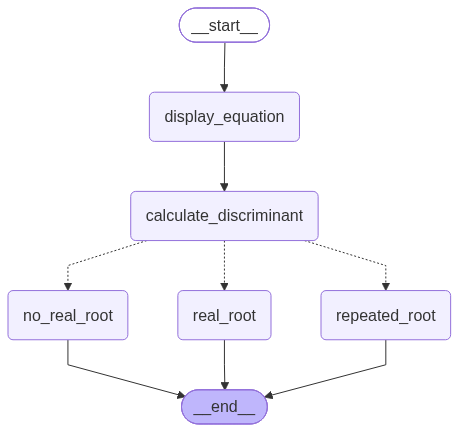

In [85]:
graph = StateGraph(QuadraticState)
graph.add_node('display_equation', display_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_root',real_root)
graph.add_node('no_real_root', no_real_root)
graph.add_node('repeated_root', repeated_root)

graph.add_edge(START, "display_equation")
graph.add_edge('display_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_root)

graph.add_edge('real_root', END)
graph.add_edge('no_real_root', END)
graph.add_edge('repeated_root', END)
workflow = graph.compile()
workflow

In [ ]:
initial_state = {'a': 4, 'b': 3, 'c': 2}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x^2 + -5x + -4 = 0', 'discriminant': 89, 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754.'}
